# Taller 2 - Punto 3: Fine-tuning de xlm-roberta-large para Analisis de Sentimientos

Este notebook implementa el fine-tuning del modelo xlm-roberta-large de Facebook para clasificacion de sentimientos en tweets en espanol.

## Objetivos:
1. Autenticacion en Hugging Face
2. Carga y preprocesamiento del dataset de Tweets
3. Tokenizacion con xlm-roberta-large
4. Configuracion y entrenamiento del modelo con class weights
5. Evaluacion con metricas de clasificacion (Accuracy, F1, Precision, Recall)
6. Visualizacion del progreso de entrenamiento
7. Subida del modelo a Hugging Face Hub

Este punto requiere GPU para entrenar xlm-roberta-large de forma eficiente.

## 3.1 Configuracion Inicial y Autenticacion en Hugging Face

Reemplaza el token con tu propio token de Hugging Face.
Puedes obtenerlo en: https://huggingface.co/settings/tokens

In [1]:
from huggingface_hub import login, HfApi

import warnings
warnings.filterwarnings('ignore')

# Cargar token desde archivo .env
import os
from pathlib import Path

env_path = Path('.env')
if env_path.exists():
    with open(env_path) as f:
        for line in f:
            if line.startswith('HUGGINGFACE_TOKEN='):
                HF_TOKEN = line.strip().split('=', 1)[1]
                break
else:
    HF_TOKEN = "TU_TOKEN_AQUI"
    print("Advertencia: Archivo .env no encontrado. Usando token por defecto.")

# Autenticacion
try:
    login(HF_TOKEN)
    print("Autenticacion exitosa en Hugging Face")
except Exception as e:
    print(f"Error en autenticacion: {e}")
    print("Por favor, verifica tu token de Hugging Face")

/home/yenreh/anaconda3/envs/pln_taller2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Autenticacion exitosa en Hugging Face


In [2]:
# Imports necesarios
import os
import re
import json
import time
import gc
import pandas as pd
import numpy as np
import torch
from torch import nn
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    TrainerCallback
)
import matplotlib.pyplot as plt
import seaborn as sns

# Importar funciones del archivo helpers
from helpers import (
    ensure_directories,
    save_experiment_results,
    load_experiment_results,
    save_training_history,
    load_training_history,
    plot_training_history
)

print(f"PyTorch version: {torch.__version__}")
print(f"GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Dispositivo GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


PyTorch version: 2.9.1+cu130
GPU disponible: True
Dispositivo GPU: NVIDIA GeForce RTX 5070
Memoria GPU disponible: 12.34 GB


## 3.2 Configuracion de Directorios y Parametros

In [3]:
# Configuracion de directorios
DATA_DIR = "./input/TASS/"
OUTPUT_DIR = "./output/punto3/"
MODELS_DIR = "./models/punto3/"
RESULTS_DIR = "./results/"

# Crear directorios necesarios
ensure_directories(3)

# Configuracion del modelo base
MODEL_NAME = "xlm-roberta-large"
MODEL_CHECKPOINT = "FacebookAI/xlm-roberta-large"
MAX_LENGTH = 256
LEARNING_RATE = 2e-5
NUM_EPOCHS = 10
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 500

# Configuracion de evaluacion
EVAL_STRATEGY = "epoch"
SAVE_STRATEGY = "epoch"
METRIC_FOR_BEST_MODEL = "f1"
EARLY_STOPPING_PATIENCE = 3

# Batch sizes a experimentar segun el taller
BATCH_SIZES = [4, 8, 16]

# Configuracion de optimizacion de memoria
GRADIENT_CHECKPOINTING = True

print("="*80)
print("CONFIGURACION DEL PUNTO 3 - FINE-TUNING XLM-ROBERTA-LARGE")
print("="*80)
print(f"\nModelo base: {MODEL_NAME}")
print(f"Checkpoint: {MODEL_CHECKPOINT}")
print(f"Max Length: {MAX_LENGTH}")
print(f"\nHIPERPARAMETROS:")
print(f"  - Batch Sizes: {BATCH_SIZES}")
print(f"  - Gradient Checkpointing: {GRADIENT_CHECKPOINTING}")
print(f"  - Learning Rate: {LEARNING_RATE}")
print(f"  - Numero de Epocas: {NUM_EPOCHS}")
print(f"  - Weight Decay: {WEIGHT_DECAY}")
print(f"  - Warmup Steps: {WARMUP_STEPS}")
print(f"  - Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")
print(f"  - Metric for Best Model: {METRIC_FOR_BEST_MODEL}")
print(f"\nDIRECTORIOS:")
print(f"  - Data: {DATA_DIR}")
print(f"  - Models: {MODELS_DIR}")
print(f"  - Output: {OUTPUT_DIR}")
print(f"  - Results: {RESULTS_DIR}")
print(f"\n{'='*80}")
print(f"Experimentos a realizar: {len(BATCH_SIZES)}")
print(f"{'='*80}")

CONFIGURACION DEL PUNTO 3 - FINE-TUNING XLM-ROBERTA-LARGE

Modelo base: xlm-roberta-large
Checkpoint: FacebookAI/xlm-roberta-large
Max Length: 256

HIPERPARAMETROS:
  - Batch Sizes: [4, 8, 16]
  - Gradient Checkpointing: True
  - Learning Rate: 2e-05
  - Numero de Epocas: 10
  - Weight Decay: 0.01
  - Warmup Steps: 500
  - Early Stopping Patience: 3
  - Metric for Best Model: f1

DIRECTORIOS:
  - Data: ./input/TASS/
  - Models: ./models/punto3/
  - Output: ./output/punto3/
  - Results: ./results/

Experimentos a realizar: 3


## 3.3 Carga y Preprocesamiento de Datos

Cargamos los datasets de tweets con sentimientos.

In [4]:
def clean_text(text):
    """
    Limpia y normaliza el texto de tweets
    """
    if not isinstance(text, str):
        return ""
    
    # Eliminar URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Normalizar menciones de usuario
    text = re.sub(r'@\w+', '@usuario', text)
    
    # Mantener hashtags pero quitar el simbolo #
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # Mantener puntuacion importante y caracteres especiales en español
    text = re.sub(r'[^\w\sáéíóúñüÁÉÍÓÚÑÜ.,!?]', ' ', text)
    
    # Eliminar espacios multiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Cargar datasets
print("Cargando datasets...")
df1 = pd.read_csv(f"{DATA_DIR}cr-tass.csv")
df2 = pd.read_csv(f"{DATA_DIR}cr1-tass.csv")

print(f"\nDataset 1 (cr-tass.csv): {len(df1)} muestras")
print(f"Dataset 2 (cr1-tass.csv): {len(df2)} muestras")

# Combinar datasets
df = pd.concat([df1, df2], ignore_index=True)
print(f"\nDataset combinado: {len(df)} muestras")

# Mostrar distribucion de clases original
print("\nDistribucion de clases (original):")
print(df['label'].value_counts())

# Filtrar clases N, NEU y P (3 clases)
df = df[df['label'].isin(['N', 'NEU', 'P'])].copy()
label_map = {'N': 0, 'NEU': 1, 'P': 2}
print(f"\nDespues de filtrar N, NEU y P: {len(df)} muestras")
print("Clases: N=Negativo (0), NEU=Neutral (1), P=Positivo (2)")

# Renombrar columnas para facilitar el uso
df = df.rename(columns={'sentencia original': 'text', 'label': 'sentiment'})

# Limpiar textos
print("\nLimpiando textos...")
df['text_clean'] = df['text'].apply(clean_text)

# Eliminar textos vacios
df = df[df['text_clean'].str.len() > 0].copy()
print(f"Despues de eliminar textos vacios: {len(df)} muestras")

# Convertir etiquetas a numeros
df['label'] = df['sentiment'].map(label_map)
num_classes = len(label_map)

# Mostrar distribucion final
print("\nDistribucion de clases (final):")
print(df['label'].value_counts())
for label_text, label_num in label_map.items():
    count = (df['label']==label_num).sum()
    print(f"Clase {label_num} ({label_text}): {count} muestras ({count/len(df)*100:.1f}%)")

# Mostrar ejemplos
print("\nEjemplos de tweets procesados:")
for i in range(3):
    print(f"\n{i+1}. Sentimiento: {df.iloc[i]['sentiment']}")
    print(f"   Original: {df.iloc[i]['text'][:100]}")
    print(f"   Limpio: {df.iloc[i]['text_clean'][:100]}")


Cargando datasets...

Dataset 1 (cr-tass.csv): 4802 muestras
Dataset 2 (cr1-tass.csv): 2443 muestras

Dataset combinado: 7245 muestras

Distribucion de clases (original):
label
N      2836
NEU    2316
P      2093
Name: count, dtype: int64

Despues de filtrar N, NEU y P: 7245 muestras
Clases: N=Negativo (0), NEU=Neutral (1), P=Positivo (2)

Limpiando textos...
Despues de eliminar textos vacios: 7245 muestras

Distribucion de clases (final):
label
0    2836
1    2316
2    2093
Name: count, dtype: int64
Clase 0 (N): 2836 muestras (39.1%)
Clase 1 (NEU): 2316 muestras (32.0%)
Clase 2 (P): 2093 muestras (28.9%)

Ejemplos de tweets procesados:

1. Sentimiento: N
   Original: No mames este pinche dolor que pedo? ya mejor llévame Diosito.
   Limpio: No mames este pinche dolor que pedo? ya mejor llévame Diosito.

2. Sentimiento: NEU
   Original: @leomall2018 Según yo era como aviso, pero ahora sí ya es oficial
   Limpio: usuario Según yo era como aviso, pero ahora sí ya es oficial

3. Sentimient

## 3.3.1 Análisis del Desbalanceo de Clases

Análisis de la distribución de clases en el dataset para identificar posibles desbalances.

ANALISIS DEL DESBALANCEO DE CLASES

Total de muestras: 7,245

Distribucion por clase:
------------------------------------------------------------
  Clase 0 (N       ): 2,836 muestras ( 39.1%)
  Clase 1 (NEU     ): 2,316 muestras ( 32.0%)
  Clase 2 (P       ): 2,093 muestras ( 28.9%)

Ratio de desbalanceo (max/min): 1.35x
  La clase mayoritaria tiene 1.4 veces mas muestras que la minoritaria

Desbalanceo moderado detectado

Grafica guardada en: ./output/punto3/class_distribution.png

Grafica guardada en: ./output/punto3/class_distribution.png


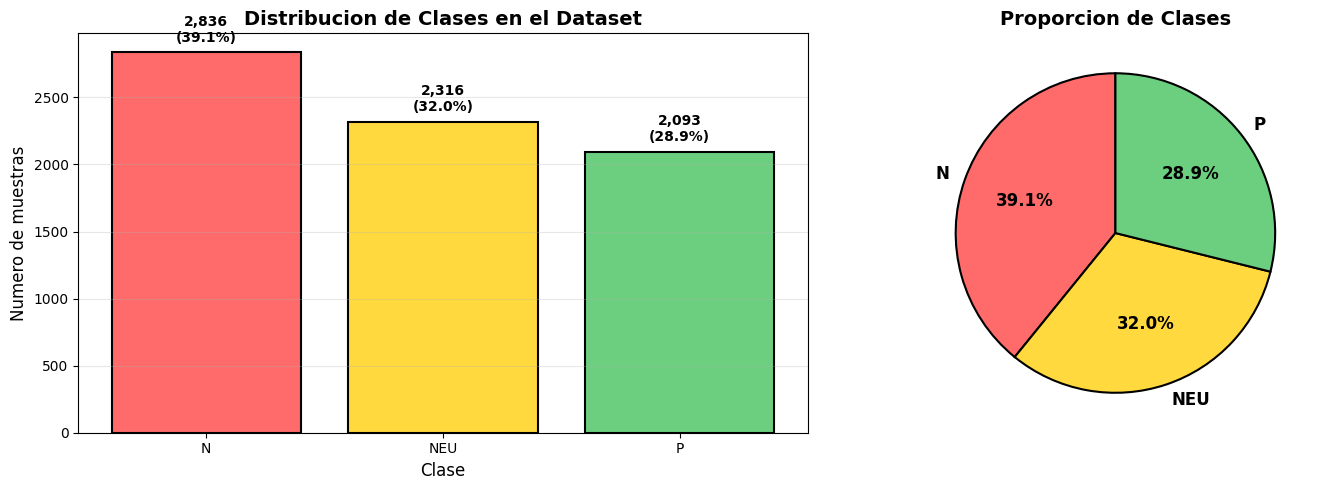

In [5]:
# Analizar desbalanceo de clases
print("="*80)
print("ANALISIS DEL DESBALANCEO DE CLASES")
print("="*80)

# Contar muestras por clase
class_counts = df['label'].value_counts().sort_index()
total_samples = len(df)

print(f"\nTotal de muestras: {total_samples:,}")
print("\nDistribucion por clase:")
print("-" * 60)

for label_num in sorted(class_counts.index):
    label_text = [k for k, v in label_map.items() if v == label_num][0]
    count = class_counts[label_num]
    percentage = (count / total_samples) * 100
    print(f"  Clase {label_num} ({label_text:8s}): {count:5,} muestras ({percentage:5.1f}%)")

# Calcular ratio de desbalanceo
max_class = class_counts.max()
min_class = class_counts.min()
imbalance_ratio = max_class / min_class

print(f"\nRatio de desbalanceo (max/min): {imbalance_ratio:.2f}x")
print(f"  La clase mayoritaria tiene {imbalance_ratio:.1f} veces mas muestras que la minoritaria")

if imbalance_ratio > 2.0:
    print("\nDesbalanceo significativo detectado (ratio > 2.0)")
    print("Se aplicaran class weights durante el entrenamiento")
else:
    print("\nDesbalanceo moderado detectado")

# Visualizar distribucion
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Grafico de barras
labels_text = [k for k, v in sorted(label_map.items(), key=lambda x: x[1])]
colors = ['#ff6b6b', '#ffd93d', '#6bcf7f']
ax1.bar(labels_text, class_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Clase', fontsize=12)
ax1.set_ylabel('Numero de muestras', fontsize=12)
ax1.set_title('Distribucion de Clases en el Dataset', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, (label, count) in enumerate(zip(labels_text, class_counts.values)):
    ax1.text(i, count + max_class*0.02, f'{count:,}\n({count/total_samples*100:.1f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Grafico de pastel
ax2.pie(class_counts.values, labels=labels_text, colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
ax2.set_title('Proporcion de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}class_distribution.png", dpi=300, bbox_inches='tight')
print(f"\nGrafica guardada en: {OUTPUT_DIR}class_distribution.png")
plt.show()

print("\n" + "="*80)

## 3.4 Division de Datos y Tokenizacion

In [6]:
# CORRECCION: Dividir como en ayuda - Solo train/eval (80-20)
# El "eval_dataset" se usa tanto para validacion durante entrenamiento como para test final
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text_clean'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Division de datos:")
print(f"- Train: {len(train_texts)} muestras (80%)")
print(f"- Validation/Test: {len(val_texts)} muestras (20%)")
print("Nota: El conjunto de validacion se usa tambien como conjunto de test")

# Crear test_texts y test_labels apuntando a val (para compatibilidad con codigo posterior)
test_texts = val_texts
test_labels = val_labels

# Verificar distribucion de clases
print("\nDistribucion de clases:")
print(f"Train - N: {train_labels.count(0)}, NEU: {train_labels.count(1)}, P: {train_labels.count(2)}")
print(f"Eval/Test - N: {test_labels.count(0)}, NEU: {test_labels.count(1)}, P: {test_labels.count(2)}")

# Cargar tokenizer
print(f"\nCargando tokenizer: {MODEL_CHECKPOINT}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
print("Tokenizer cargado exitosamente")

# Funcion de tokenizacion
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

# Crear datasets de HuggingFace
train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels})
eval_dataset = Dataset.from_dict({'text': val_texts, 'label': val_labels})

# Tokenizar datasets
print("\nTokenizando datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
eval_dataset = eval_dataset.map(tokenize_function, batched=True)

# Establecer formato
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
eval_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

# Crear alias para compatibilidad
val_dataset = eval_dataset
test_dataset = eval_dataset

print("Tokenizacion completada")

# Mostrar ejemplo tokenizado
print("\nEjemplo de tokenizacion:")
print(f"Texto: {train_texts[0][:100]}")
print(f"Tokens: {tokenizer.convert_ids_to_tokens(train_dataset[0]['input_ids'])[:20]}")


Division de datos:
- Train: 5796 muestras (80%)
- Validation/Test: 1449 muestras (20%)
Nota: El conjunto de validacion se usa tambien como conjunto de test

Distribucion de clases:
Train - N: 2269, NEU: 1853, P: 1674
Eval/Test - N: 567, NEU: 463, P: 419

Cargando tokenizer: FacebookAI/xlm-roberta-large
Tokenizer cargado exitosamente

Tokenizando datasets...
Tokenizer cargado exitosamente

Tokenizando datasets...


Map: 100%|██████████| 1449/1449 [00:00<00:00, 18499.89 examples/s]

Tokenizacion completada

Ejemplo de tokenizacion:
Texto: usuario jajaja, chalé, te extraño tanto que voy a enloquecer ya ven a verme
Tokens: ['<s>', '▁usuario', '▁ja', 'ja', 'ja', ',', '▁cha', 'lé', ',', '▁te', '▁extraño', '▁tanto', '▁que', '▁voy', '▁a', '▁en', 'lo', 'que', 'cer', '▁ya']


## 3.5 Configuracion del Modelo con Class Weights

Configuramos el modelo con pesos de clase para manejar el desbalanceo de datos.

In [7]:
# Calcular class weights para balancear clases (dinamico segun num_classes)
unique_labels = sorted(df['label'].unique())
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(unique_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
print(f"Class weights calculados para {len(class_weights)} clases:")
for i, weight in enumerate(class_weights):
    label_text = [k for k, v in label_map.items() if v == i][0]
    print(f"  Clase {i} ({label_text}): {weight:.4f}")
print("\nSe aplicara weighted loss durante el entrenamiento")


Class weights calculados para 3 clases:
  Clase 0 (N): 0.8515
  Clase 1 (NEU): 1.0426
  Clase 2 (P): 1.1541

Se aplicara weighted loss durante el entrenamiento


## 3.6 Funciones de Metricas y Callbacks

In [8]:
# Funcion para calcular metricas
def compute_metrics(eval_pred):
    """
    Calcula accuracy, F1, precision y recall
    """
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    precision = precision_score(labels, predictions, average='weighted')
    recall = recall_score(labels, predictions, average='weighted')
    
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Callback para guardar historial de entrenamiento
class MetricsHistoryCallback(TrainerCallback):
    def __init__(self):
        self.history = {
            'train_loss': [],
            'eval_loss': [],
            'eval_accuracy': [],
            'eval_f1': [],
            'eval_precision': [],
            'eval_recall': [],
            'epoch': []
        }
    
    def on_evaluate(self, args, state, control, metrics, **kwargs):
        """Guardar metricas despues de cada evaluacion"""
        self.history['epoch'].append(state.epoch)
        self.history['eval_loss'].append(metrics.get('eval_loss', None))
        self.history['eval_accuracy'].append(metrics.get('eval_accuracy', None))
        self.history['eval_f1'].append(metrics.get('eval_f1', None))
        self.history['eval_precision'].append(metrics.get('eval_precision', None))
        self.history['eval_recall'].append(metrics.get('eval_recall', None))
    
    def on_log(self, args, state, control, logs, **kwargs):
        """Guardar loss de entrenamiento"""
        if 'loss' in logs:
            self.history['train_loss'].append(logs['loss'])

# Definir Trainer personalizado con weighted loss
class WeightedLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Compute loss con class weights
        Nota: num_items_in_batch es un parametro nuevo en transformers 4.x
        """
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Aplicar weighted cross entropy loss
        if self.class_weights is not None:
            weights = self.class_weights.to(logits.device)
            loss_fct = nn.CrossEntropyLoss(weight=weights)
        else:
            loss_fct = nn.CrossEntropyLoss()
        
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

print("Funciones de metricas y callbacks configurados:")
print("  - compute_metrics: Calcula accuracy, F1, precision y recall")
print("  - MetricsHistoryCallback: Guarda el historial de entrenamiento")
print("  - WeightedLossTrainer: Trainer con loss ponderado por clase")

Funciones de metricas y callbacks configurados:
  - compute_metrics: Calcula accuracy, F1, precision y recall
  - MetricsHistoryCallback: Guarda el historial de entrenamiento
  - WeightedLossTrainer: Trainer con loss ponderado por clase


## 3.6 Funciones de Metricas y Callbacks

Configuramos las funciones para calcular metricas y callbacks para monitorear el entrenamiento.

In [ ]:
# Diccionario para guardar todos los resultados
all_experiments = {}

# Iterar sobre cada batch size
for batch_size in BATCH_SIZES:
    print("\n" + "="*100)
    print(f"EXPERIMENTO: BATCH_SIZE = {batch_size}")
    print("="*100)
    
    # Limpiar memoria antes de cada experimento
    if torch.cuda.is_available():
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        gc.collect()
        torch.cuda.empty_cache()
        print(f"Memoria GPU limpiada antes del experimento")
        print(f"  VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
        print(f"  VRAM libre: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0)) / 1e9:.2f} GB")
        print(f"  VRAM asignada: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
    
    # Crear callback para este experimento
    metrics_callback = MetricsHistoryCallback()
    
    # Cargar modelo fresco para cada experimento
    print(f"\nCargando modelo: {MODEL_CHECKPOINT}")
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=num_classes,
        problem_type="single_label_classification"
    )
    
    # Activar gradient checkpointing para optimizacion de memoria
    if GRADIENT_CHECKPOINTING:
        model.gradient_checkpointing_enable()
        print("Gradient Checkpointing activado")
    
    print(f"Modelo cargado - Parametros: {sum(p.numel() for p in model.parameters()):,}")
    
    # Configurar argumentos de entrenamiento
    experiment_output_dir = f"{OUTPUT_DIR}batch_size_{batch_size}/"
    os.makedirs(experiment_output_dir, exist_ok=True)
    
    training_args = TrainingArguments(
        output_dir=experiment_output_dir,
        eval_strategy=EVAL_STRATEGY,
        save_strategy=SAVE_STRATEGY,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=0.1,
        logging_dir=f"{experiment_output_dir}logs/",
        logging_steps=10,
        load_best_model_at_end=True,
        metric_for_best_model=METRIC_FOR_BEST_MODEL,
        greater_is_better=True,
        save_total_limit=2,
        fp16=torch.cuda.is_available(),
        report_to="none",
        push_to_hub=False,
        seed=42,
        dataloader_num_workers=0
    )
    
    # Crear trainer con weighted loss
    trainer = WeightedLossTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[metrics_callback, EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
        class_weights=class_weights
    )
    
    # Entrenar modelo
    print(f"\nIniciando entrenamiento con batch_size={batch_size}...")
    print(f"Tiempo de inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
    try:
        start_time = time.time()
        trainer.train()
        training_time = time.time() - start_time
        
        print(f"\nEntrenamiento completado en {training_time/60:.2f} minutos")
        
    except RuntimeError as e:
        if "out of memory" in str(e).lower() or "oom" in str(e).lower():
            print(f"\n{'='*100}")
            print(f"ERROR: Memoria insuficiente para batch_size={batch_size}")
            print(f"{'='*100}")
            print(f"Detalles: {e}")
            print(f"Saltando experimento con batch_size={batch_size}\n")
            
            # Limpiar memoria y continuar
            del model
            del trainer
            gc.collect()
            torch.cuda.empty_cache()
            continue
        else:
            raise e
    
    # Guardar modelo
    model_output_dir = f"{MODELS_DIR}batch_size_{batch_size}/"
    os.makedirs(model_output_dir, exist_ok=True)
    trainer.save_model(model_output_dir)
    tokenizer.save_pretrained(model_output_dir)
    print(f"Modelo guardado en: {model_output_dir}")
    
    # Evaluar en test set
    print("\nEvaluando en test set...")
    test_results = trainer.predict(test_dataset)
    test_predictions = np.argmax(test_results.predictions, axis=1)
    
    # Calcular metricas de test manualmente
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_f1 = f1_score(test_labels, test_predictions, average='weighted')
    test_precision = precision_score(test_labels, test_predictions, average='weighted')
    test_recall = recall_score(test_labels, test_predictions, average='weighted')
    
    test_metrics = {
        'test_loss': test_results.metrics['test_loss'],
        'test_accuracy': test_accuracy,
        'test_f1': test_f1,
        'test_precision': test_precision,
        'test_recall': test_recall
    }
    
    # Calcular matriz de confusion
    confusion_mat = confusion_matrix(test_labels, test_predictions)
    
    # Guardar resultados del experimento (key como string)
    all_experiments[f'batch_size_{batch_size}'] = {
        'batch_size': batch_size,
        'training_time': training_time,
        'training_history': metrics_callback.history,
        'test_metrics': test_metrics,
        'confusion_matrix': confusion_mat.tolist(),
        'model_path': model_output_dir
    }
    
    print(f"\nResultados del experimento (batch_size={batch_size}):")
    print(f"  Test Loss: {test_metrics['test_loss']:.4f}")
    print(f"  Test Accuracy: {test_metrics['test_accuracy']:.4f}")
    print(f"  Test F1: {test_metrics['test_f1']:.4f}")
    print(f"  Test Precision: {test_metrics['test_precision']:.4f}")
    print(f"  Test Recall: {test_metrics['test_recall']:.4f}")
    print(f"  Training Time: {training_time/60:.2f} minutos")
    
    # Limpiar memoria despues del experimento
    del model
    del trainer
    if torch.cuda.is_available():
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        print(f"\nMemoria GPU limpiada despues del experimento")

print("\n" + "="*100)
print("TODOS LOS EXPERIMENTOS COMPLETADOS")
print("="*100)

# Guardar todos los resultados en JSON
print("\nGuardando resultados en JSON...")
results_json = {
    'model_info': {
        'model_name': MODEL_NAME,
        'model_checkpoint': MODEL_CHECKPOINT,
        'task': 'sentiment_analysis',
        'num_classes': num_classes,
        'labels': label_map
    },
    'dataset_info': {
        'total_samples': len(df),
        'train_samples': len(train_texts),
        'test_samples': len(test_texts),
        'class_distribution': {
            'negative': int((df['label']==0).sum()),
            'neutral': int((df['label']==1).sum()),
            'positive': int((df['label']==2).sum())
        }
    },
    'hyperparameters': {
        'max_length': MAX_LENGTH,
        'learning_rate': LEARNING_RATE,
        'num_epochs': NUM_EPOCHS,
        'weight_decay': WEIGHT_DECAY,
        'warmup_steps': WARMUP_STEPS,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
        'gradient_checkpointing': GRADIENT_CHECKPOINTING,
        'batch_sizes': BATCH_SIZES
    },
    'experiments': {}
}

# Agregar resultados de cada experimento
for exp_name, exp_results in all_experiments.items():
    batch_size = exp_results['batch_size']
    results_json['experiments'][f'batch_size_{batch_size}'] = {
        'batch_size': batch_size,
        'training_time_minutes': exp_results['training_time'] / 60,
        'test_metrics': exp_results['test_metrics'],
        'confusion_matrix': exp_results['confusion_matrix'],
        'model_path': exp_results['model_path']
    }

# Guardar en archivo JSON
results_json_path = f"{RESULTS_DIR}punto3_results.json"
with open(results_json_path, 'w', encoding='utf-8') as f:
    json.dump(results_json, f, indent=2, ensure_ascii=False)

print(f"Resultados guardados en: {results_json_path}")



EXPERIMENTO: BATCH_SIZE = 4
Memoria GPU limpiada antes del experimento
  VRAM total: 12.34 GB
  VRAM libre: 12.34 GB
  VRAM asignada: 0.00 GB

Cargando modelo: FacebookAI/xlm-roberta-large
Memoria GPU limpiada antes del experimento
  VRAM total: 12.34 GB
  VRAM libre: 12.34 GB
  VRAM asignada: 0.00 GB

Cargando modelo: FacebookAI/xlm-roberta-large


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Gradient Checkpointing activado
Modelo cargado - Parametros: 559,893,507

Iniciando entrenamiento con batch_size=4...
Tiempo de inicio: 2025-11-17 14:27:55

Iniciando entrenamiento con batch_size=4...
Tiempo de inicio: 2025-11-17 14:27:55


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.076000,1.103547,0.289165,0.129722,0.083616,0.289165
2,1.092100,1.100650,0.319531,0.154752,0.102100,0.319531
3,1.105700,1.098860,0.391304,0.220109,0.153119,0.391304
4,1.121700,1.098476,0.319531,0.154752,0.102100,0.319531
5,1.172300,1.103243,0.319531,0.154752,0.102100,0.319531
6,1.116600,1.098385,0.391304,0.220109,0.153119,0.391304



Entrenamiento completado en 21.66 minutos
Modelo guardado en: ./models/punto3/batch_size_4/

Evaluando en test set...
Modelo guardado en: ./models/punto3/batch_size_4/

Evaluando en test set...


...

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Gradient Checkpointing activado
Modelo cargado - Parametros: 559,893,507

Iniciando entrenamiento con batch_size=16...
Tiempo de inicio: 2025-11-17 14:59:56

Iniciando entrenamiento con batch_size=16...
Tiempo de inicio: 2025-11-17 14:59:56


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.780900,0.802222,0.690821,0.679566,0.684477,0.690821
2,0.690300,0.734677,0.685300,0.684617,0.684978,0.685300
3,0.712900,0.767912,0.673568,0.667105,0.667724,0.673568
4,0.482600,0.844735,0.690131,0.689938,0.690363,0.690131
5,0.339100,0.907819,0.694962,0.686280,0.687869,0.694962
6,0.301500,1.213351,0.684610,0.682928,0.682643,0.684610
7,0.300300,1.408827,0.684610,0.683284,0.683089,0.684610



Entrenamiento completado en 14.21 minutos
Modelo guardado en: ./models/punto3/batch_size_16/

Evaluando en test set...
Modelo guardado en: ./models/punto3/batch_size_16/

Evaluando en test set...



Resultados del experimento (batch_size=16):
  Test Loss: 0.8447
  Test Accuracy: 0.6901
  Test F1: 0.6899
  Test Precision: 0.6904
  Test Recall: 0.6901
  Training Time: 14.21 minutos

Memoria GPU limpiada despues del experimento

TODOS LOS EXPERIMENTOS COMPLETADOS


## 3.7 Experimentos con Diferentes Batch Sizes

Modelo con 10 epocas y 3 batch sizes: 4, 8 y 16.

COMPARACION DE RESULTADOS - TODOS LOS EXPERIMENTOS

  Batch Size  Test Accuracy  Test F1  Test Precision  Test Recall  Test Loss  Training Time (min)
          4       0.391304 0.220109        0.153119     0.391304   1.098860            21.656367
          8       0.506556 0.431692        0.543134     0.506556   1.071715            10.023844
         16       0.690131 0.689938        0.690363     0.690131   0.844735            14.212178

MEJOR MODELO: Batch Size = 16
  - F1 Score: 0.6899
  - Accuracy: 0.6901
  - Precision: 0.6904
  - Recall: 0.6901

Grafica comparativa guardada en: ./output/punto3/experiments_comparison.png

Grafica comparativa guardada en: ./output/punto3/experiments_comparison.png


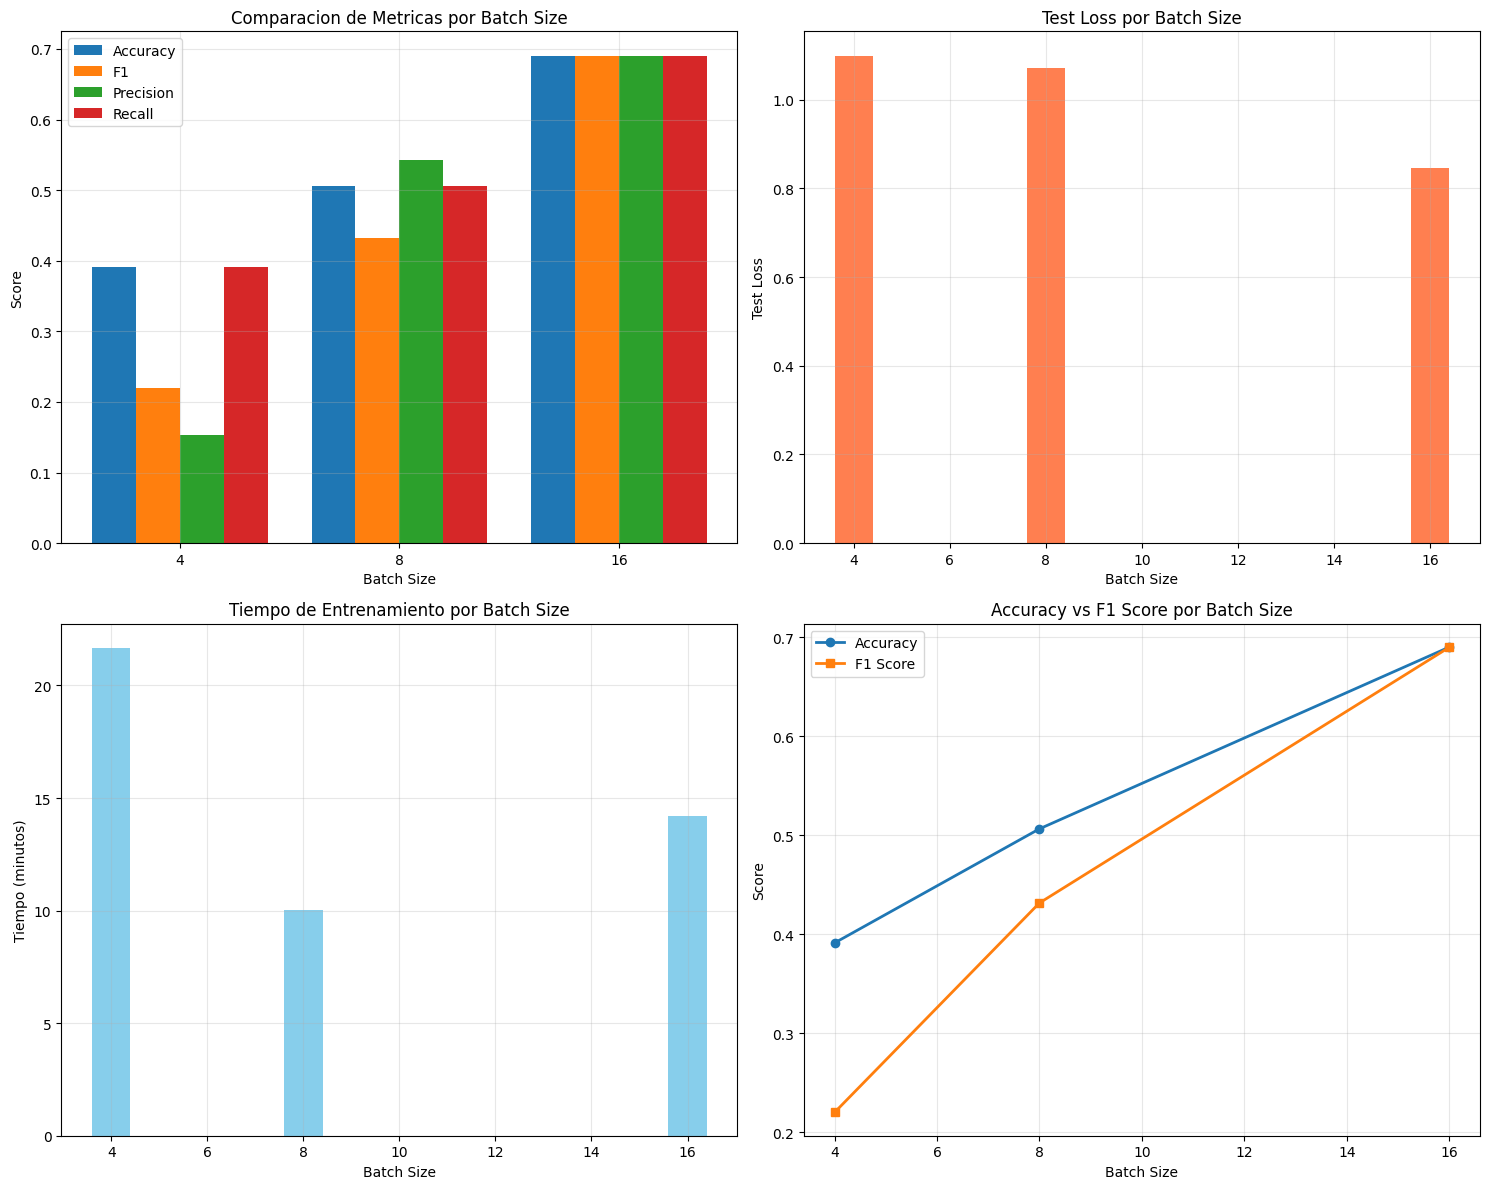

Tabla comparativa guardada en: ./results/punto3_experiments_comparison.csv


In [10]:
# Crear DataFrame con resultados comparativos
comparison_data = []
for exp_name, exp_results in all_experiments.items():
    batch_size = exp_results['batch_size']
    test_metrics = exp_results['test_metrics']
    train_time = exp_results['training_time']
    
    comparison_data.append({
        'Batch Size': batch_size,
        'Test Accuracy': test_metrics['test_accuracy'],
        'Test F1': test_metrics['test_f1'],
        'Test Precision': test_metrics['test_precision'],
        'Test Recall': test_metrics['test_recall'],
        'Test Loss': test_metrics['test_loss'],
        'Training Time (min)': train_time / 60
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Batch Size')

print("="*100)
print("COMPARACION DE RESULTADOS - TODOS LOS EXPERIMENTOS")
print("="*100)
print("\n", comparison_df.to_string(index=False))

# Identificar mejor modelo por F1
best_idx = comparison_df['Test F1'].idxmax()
best_batch = int(comparison_df.loc[best_idx, 'Batch Size'])

print(f"\n{'='*100}")
print(f"MEJOR MODELO: Batch Size = {best_batch}")
print(f"{'='*100}")
print(f"  - F1 Score: {comparison_df.loc[best_idx, 'Test F1']:.4f}")
print(f"  - Accuracy: {comparison_df.loc[best_idx, 'Test Accuracy']:.4f}")
print(f"  - Precision: {comparison_df.loc[best_idx, 'Test Precision']:.4f}")
print(f"  - Recall: {comparison_df.loc[best_idx, 'Test Recall']:.4f}")

# Visualizaciones comparativas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Comparacion de metricas principales
ax = axes[0, 0]
metrics = ['Test Accuracy', 'Test F1', 'Test Precision', 'Test Recall']
x = np.arange(len(comparison_df))
width = 0.2
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, comparison_df[metric], width, label=metric.replace('Test ', ''))
ax.set_xlabel('Batch Size')
ax.set_ylabel('Score')
ax.set_title('Comparacion de Metricas por Batch Size')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Batch Size'])
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Test Loss comparison
ax = axes[0, 1]
ax.bar(comparison_df['Batch Size'], comparison_df['Test Loss'], color='coral')
ax.set_xlabel('Batch Size')
ax.set_ylabel('Test Loss')
ax.set_title('Test Loss por Batch Size')
ax.grid(True, alpha=0.3)

# 3. Training Time comparison
ax = axes[1, 0]
ax.bar(comparison_df['Batch Size'], comparison_df['Training Time (min)'], color='skyblue')
ax.set_xlabel('Batch Size')
ax.set_ylabel('Tiempo (minutos)')
ax.set_title('Tiempo de Entrenamiento por Batch Size')
ax.grid(True, alpha=0.3)

# 4. Accuracy vs F1
ax = axes[1, 1]
ax.plot(comparison_df['Batch Size'], comparison_df['Test Accuracy'], 'o-', label='Accuracy', linewidth=2)
ax.plot(comparison_df['Batch Size'], comparison_df['Test F1'], 's-', label='F1 Score', linewidth=2)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Score')
ax.set_title('Accuracy vs F1 Score por Batch Size')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
comparison_plot_path = f"{OUTPUT_DIR}experiments_comparison.png"
plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
print(f"\nGrafica comparativa guardada en: {comparison_plot_path}")
plt.show()

# Guardar comparacion en CSV
comparison_csv_path = f"{RESULTS_DIR}punto3_experiments_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)
print(f"Tabla comparativa guardada en: {comparison_csv_path}")


## 3.8 Visualizacion del Historial de Entrenamiento

Visualizamos el progreso de entrenamiento para cada experimento y la matriz de confusion del mejor modelo.


VISUALIZANDO: Batch Size = 4
Grafica guardada en: ./output/punto3/batch_size_4/training_history.png
Grafica guardada en: ./output/punto3/batch_size_4/training_history.png


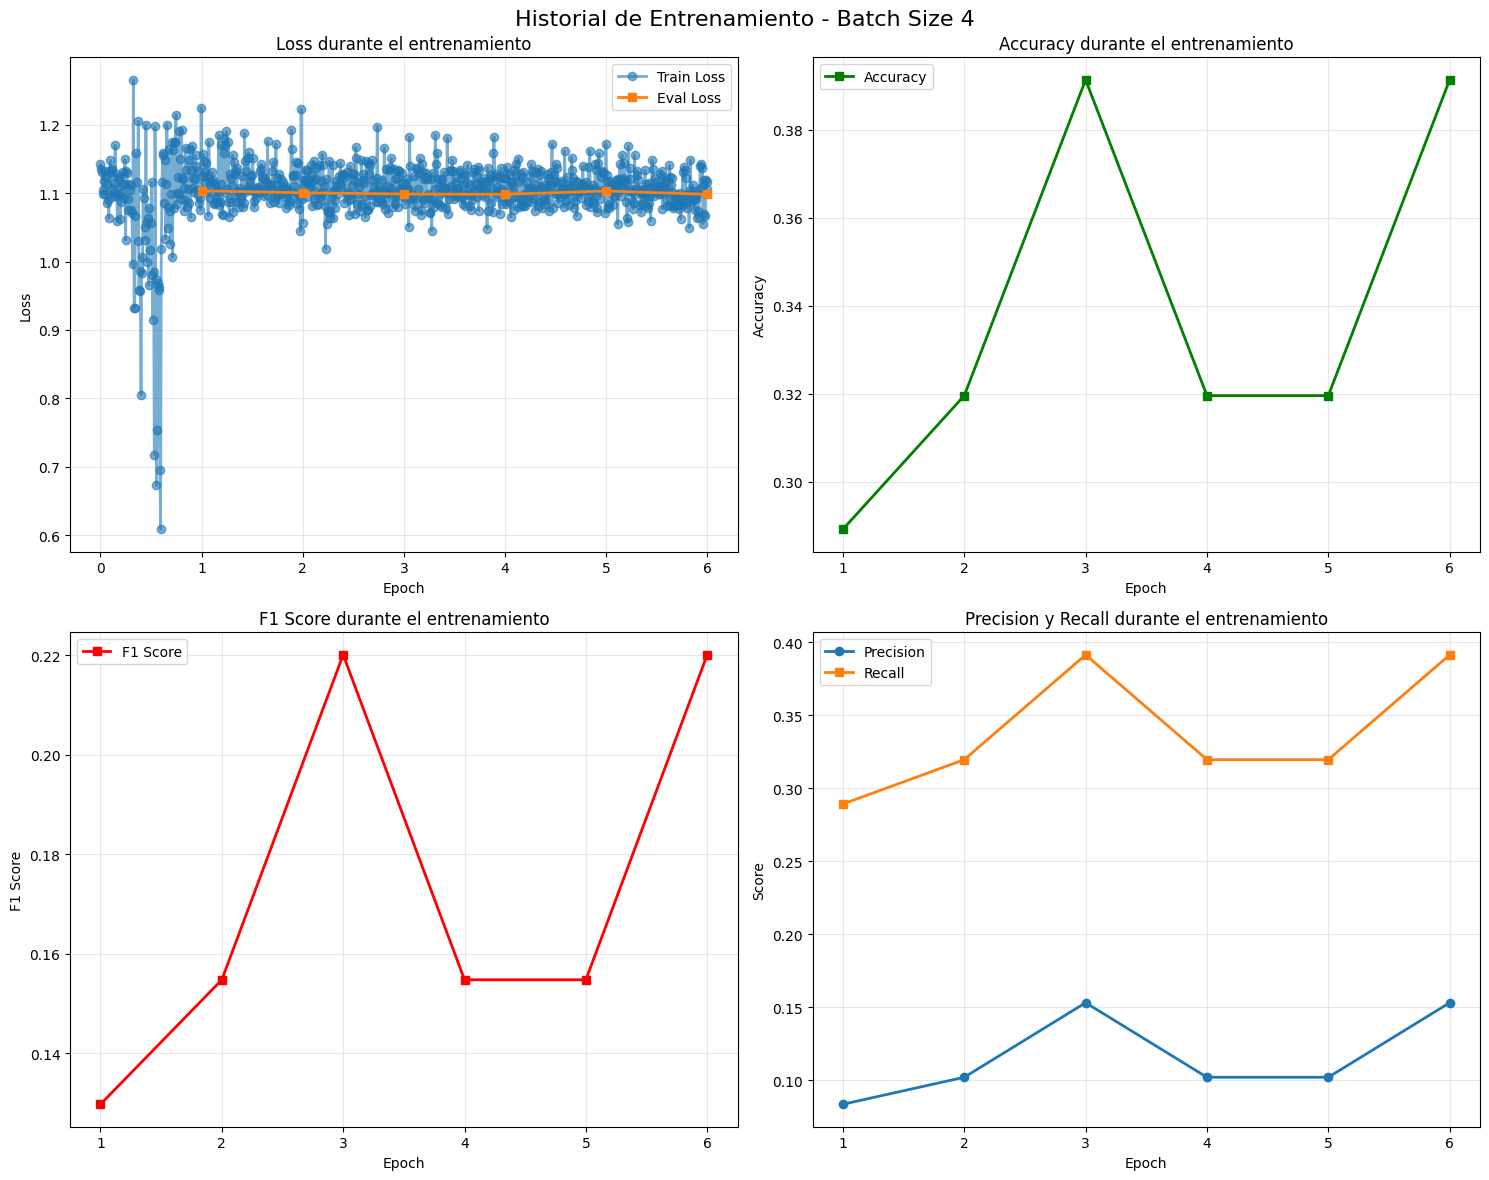


VISUALIZANDO: Batch Size = 8
Grafica guardada en: ./output/punto3/batch_size_8/training_history.png
Grafica guardada en: ./output/punto3/batch_size_8/training_history.png


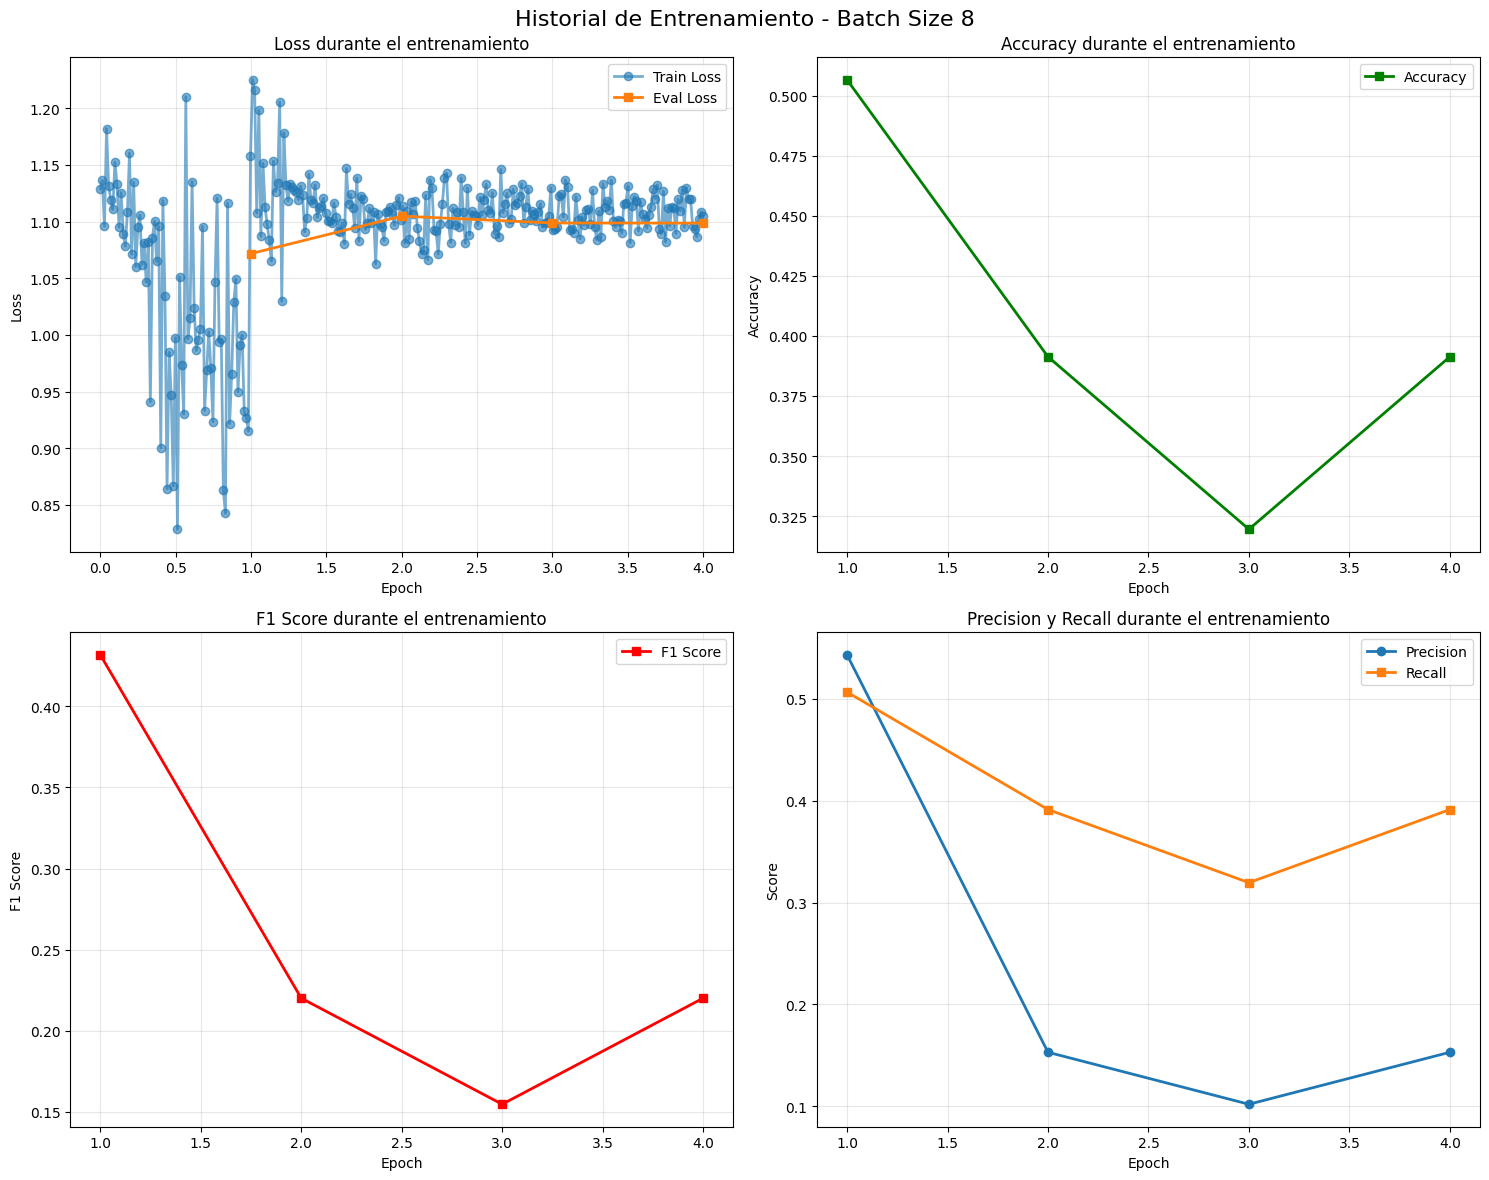


VISUALIZANDO: Batch Size = 16
Grafica guardada en: ./output/punto3/batch_size_16/training_history.png
Grafica guardada en: ./output/punto3/batch_size_16/training_history.png


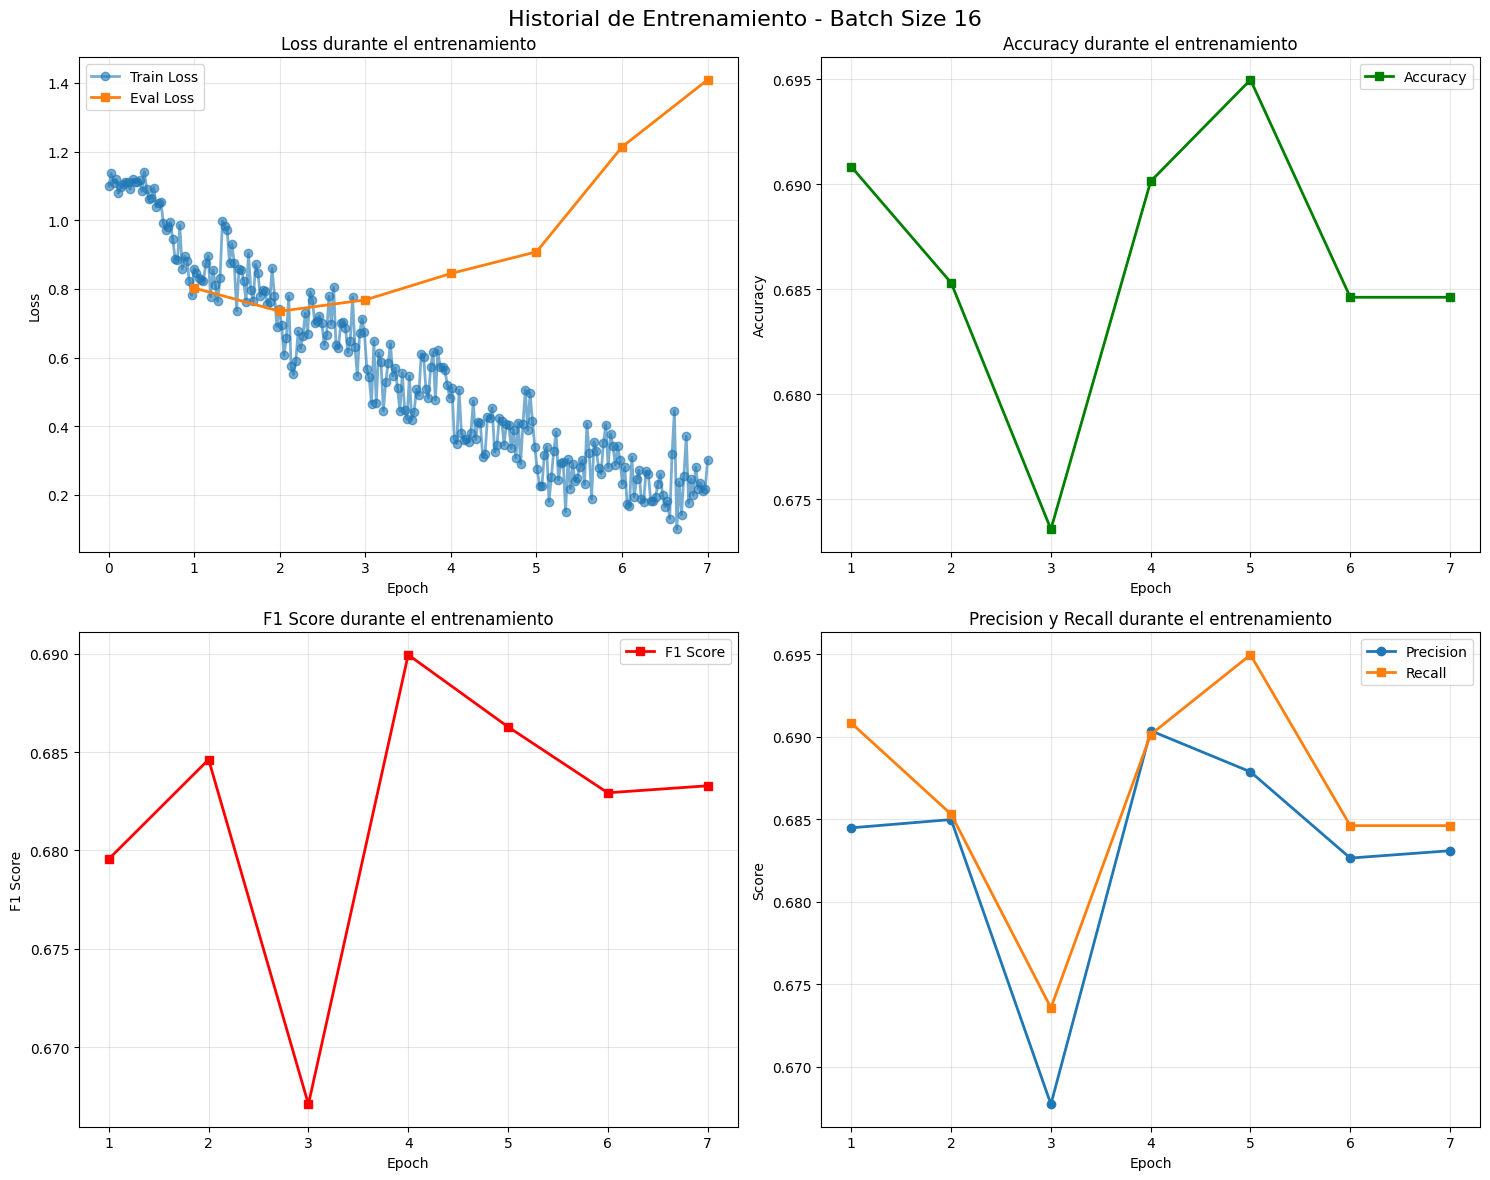


MATRIZ DE CONFUSION - MEJOR MODELO (Batch Size: 16)

                  Pred Negativo    Pred Neutral   Pred Positivo
Real Negativo               414             125              28
Real Neutral                111             261              91
Real Positivo                19              75             325

Matriz de confusion guardada en: ./output/punto3/best_model_confusion_matrix.png

Matriz de confusion guardada en: ./output/punto3/best_model_confusion_matrix.png


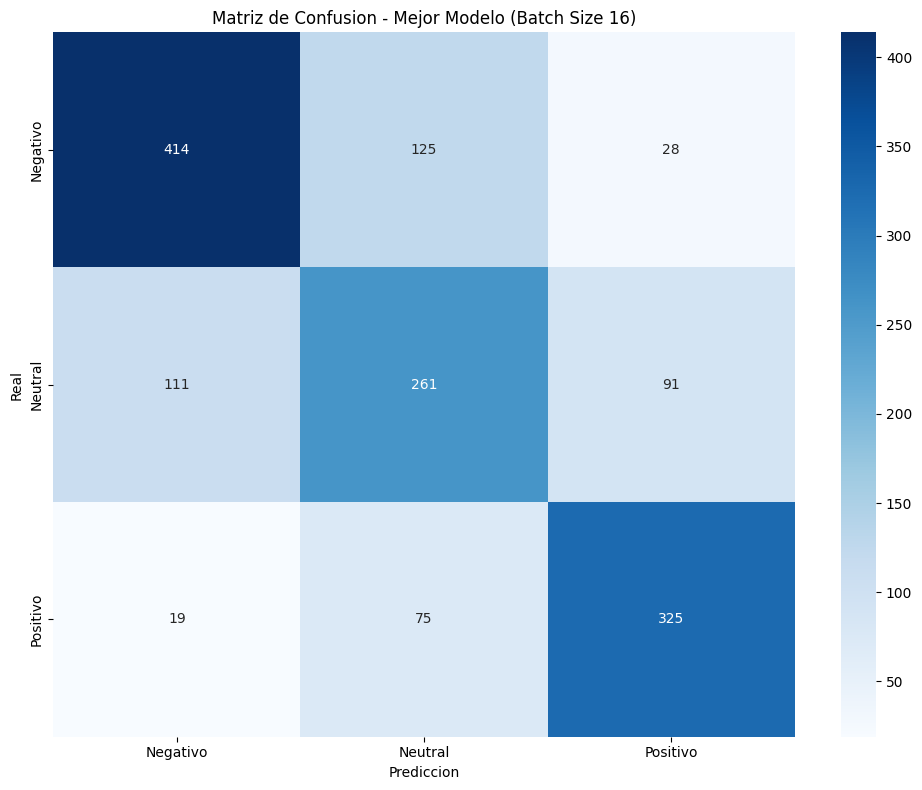

In [11]:
# Crear visualizaciones para cada experimento
for batch_size in BATCH_SIZES:
    exp_name = f'batch_size_{batch_size}'
    
    if exp_name not in all_experiments:
        continue
        
    history = all_experiments[exp_name]['training_history']
    
    print(f"\n{'='*80}")
    print(f"VISUALIZANDO: Batch Size = {batch_size}")
    print(f"{'='*80}")
    
    # Crear figura con subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'Historial de Entrenamiento - Batch Size {batch_size}', fontsize=16)
    
    # Obtener epochs (considerando que puede haber mas train_loss que eval_loss)
    num_epochs = len(history['epoch'])
    epochs = history['epoch']
    
    # 1. Loss (train y eval)
    ax = axes[0, 0]
    if history['train_loss']:
        train_steps = np.linspace(0, num_epochs, len(history['train_loss']))
        ax.plot(train_steps, history['train_loss'], 'o-', label='Train Loss', alpha=0.6, linewidth=2)
    if history['eval_loss']:
        ax.plot(epochs, history['eval_loss'], 's-', label='Eval Loss', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss durante el entrenamiento')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Accuracy
    ax = axes[0, 1]
    if history['eval_accuracy']:
        ax.plot(epochs, history['eval_accuracy'], 's-', label='Accuracy', color='green', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.set_title('Accuracy durante el entrenamiento')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # 3. F1 Score
    ax = axes[1, 0]
    if history['eval_f1']:
        ax.plot(epochs, history['eval_f1'], 's-', label='F1 Score', color='red', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('F1 Score')
        ax.set_title('F1 Score durante el entrenamiento')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # 4. Precision y Recall
    ax = axes[1, 1]
    if history['eval_precision']:
        ax.plot(epochs, history['eval_precision'], 'o-', label='Precision', linewidth=2)
    if history['eval_recall']:
        ax.plot(epochs, history['eval_recall'], 's-', label='Recall', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Score')
        ax.set_title('Precision y Recall durante el entrenamiento')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    history_plot_path = f"{OUTPUT_DIR}batch_size_{batch_size}/training_history.png"
    plt.savefig(history_plot_path, dpi=300, bbox_inches='tight')
    print(f"Grafica guardada en: {history_plot_path}")
    plt.show()

# Visualizar matriz de confusion del mejor modelo
best_exp_name = f'batch_size_{best_batch}'
best_cm = np.array(all_experiments[best_exp_name]['confusion_matrix'])

print(f"\n{'='*80}")
print(f"MATRIZ DE CONFUSION - MEJOR MODELO (Batch Size: {best_batch})")
print(f"{'='*80}")
print(f"\n{'':15} {'Pred Negativo':>15} {'Pred Neutral':>15} {'Pred Positivo':>15}")
print(f"{'Real Negativo':<15} {best_cm[0,0]:>15} {best_cm[0,1]:>15} {best_cm[0,2]:>15}")
print(f"{'Real Neutral':<15} {best_cm[1,0]:>15} {best_cm[1,1]:>15} {best_cm[1,2]:>15}")
print(f"{'Real Positivo':<15} {best_cm[2,0]:>15} {best_cm[2,1]:>15} {best_cm[2,2]:>15}")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negativo', 'Neutral', 'Positivo'],
            yticklabels=['Negativo', 'Neutral', 'Positivo'],
            ax=ax)
ax.set_xlabel('Prediccion')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusion - Mejor Modelo (Batch Size {best_batch})')
plt.tight_layout()
best_cm_path = f"{OUTPUT_DIR}best_model_confusion_matrix.png"
plt.savefig(best_cm_path, dpi=300, bbox_inches='tight')
print(f"\nMatriz de confusion guardada en: {best_cm_path}")
plt.show()


## 3.10 Verificacion de Archivos para HuggingFace

Verificamos que todos los archivos necesarios esten generados antes de subir.

In [12]:
# Verificar archivos del mejor modelo
print("="*80)
print(f"VERIFICACIÓN DE ARCHIVOS DEL MEJOR MODELO")
print("="*80)

if 'all_experiments' in globals() and len(all_experiments) > 0:
    # Obtener el mejor modelo (best_batch ya está calculado)
    best_model_dir = all_experiments[f'batch_size_{best_batch}']['model_path']
    
    print(f"\nMejor modelo: Batch Size {best_batch}")
    print(f"Directorio: {best_model_dir}")
    print(f"\nF1 Score: {all_experiments[f'batch_size_{best_batch}']['test_metrics']['test_f1']:.4f}")
    print(f"Accuracy: {all_experiments[f'batch_size_{best_batch}']['test_metrics']['test_accuracy']:.4f}")
    print()
    
    # Archivos necesarios para HuggingFace
    required_files = {
        'config.json': 'Configuración del modelo',
        'model.safetensors': 'Pesos del modelo (SafeTensors)',
        'tokenizer_config.json': 'Configuración del tokenizer',
        'tokenizer.json': 'Tokenizer',
        'special_tokens_map.json': 'Mapeo de tokens especiales'
    }
    
    print("="*80)
    print("ARCHIVOS REQUERIDOS:")
    print("="*80)
    
    all_present = True
    for filename, description in required_files.items():
        filepath = Path(best_model_dir) / filename
        exists = filepath.exists()
        all_present = all_present and exists
        status = "[OK]" if exists else "[-]"
        size = f"({filepath.stat().st_size / 1024:.1f} KB)" if exists else ""
        print(f"{status} {filename:<30} {description:<35} {size}")
    
    # Resumen
    print("\n" + "="*80)
    print("RESUMEN:")
    print("="*80)
    
    if all_present:
        print("Todos los archivos necesarios están presentes")
        print("El modelo está listo para subir a HuggingFace")
        print("\nPara subirlo:")
        print("1. Descomentar y ejecutar la celda anterior (celda 22)")
        print("2. Asegurarse de estar autenticado en HuggingFace")
        print("3. Verificar que el token tenga permisos de escritura")
    else:
        print("Faltan algunos archivos necesarios")
        print("Asegúrate de que el entrenamiento se completó correctamente")
    
    # Información adicional
    print("\n" + "="*80)
    print("INFORMACIÓN DEL MODELO:")
    print("="*80)
    print(f"Tipo: XLM-RoBERTa Large")
    print(f"Tarea: Clasificación de Sentimientos (Multiclase)")
    print(f"Idioma: Español")
    print(f"Dataset: TASS (Twitter)")
    print(f"Clases: 0=Negativo, 1=Neutral, 2=Positivo")
    print(f"Tamaño del modelo: ~2.2 GB (559M parámetros)")
    
    # Mostrar todos los archivos en el directorio
    print("\n" + "="*80)
    print("ARCHIVOS EN EL DIRECTORIO:")
    print("="*80)
    
    if Path(best_model_dir).exists():
        all_files = sorted(Path(best_model_dir).rglob('*'))
        for filepath in all_files:
            if filepath.is_file():
                relative_path = filepath.relative_to(best_model_dir)
                size_mb = filepath.stat().st_size / 1024 / 1024
                print(f"  {relative_path} ({size_mb:.1f} MB)")
    
else:
    print("\nEl entrenamiento aún no se ha completado")
    print("Ejecuta primero la celda de entrenamiento (celda 16)")
    print("Una vez completado, vuelve a ejecutar esta celda para verificar")

print("\n" + "="*80)


VERIFICACIÓN DE ARCHIVOS DEL MEJOR MODELO

Mejor modelo: Batch Size 16
Directorio: ./models/punto3/batch_size_16/

F1 Score: 0.6899
Accuracy: 0.6901

ARCHIVOS REQUERIDOS:
[OK] config.json                    Configuración del modelo            (0.9 KB)
[OK] model.safetensors              Pesos del modelo (SafeTensors)      (2187131.6 KB)
[OK] tokenizer_config.json          Configuración del tokenizer         (1.2 KB)
[OK] tokenizer.json                 Tokenizer                           (16682.6 KB)
[OK] special_tokens_map.json        Mapeo de tokens especiales          (0.3 KB)

RESUMEN:
Todos los archivos necesarios están presentes
El modelo está listo para subir a HuggingFace

Para subirlo:
1. Descomentar y ejecutar la celda anterior (celda 22)
2. Asegurarse de estar autenticado en HuggingFace
3. Verificar que el token tenga permisos de escritura

INFORMACIÓN DEL MODELO:
Tipo: XLM-RoBERTa Large
Tarea: Clasificación de Sentimientos (Multiclase)
Idioma: Español
Dataset: TASS (Twitter)

In [13]:
# CONCLUSIONES FINALES

print("="*80)
print("RESUMEN FINAL DE EXPERIMENTOS - TAREA 2 PUNTO 3")
print("="*80)
print()
print(f"Modelo base: {MODEL_NAME}")
print(f"Dataset: TASS (Spanish Twitter Sentiment)")
print(f"Total de muestras: {len(df):,}")
print(f"Distribución: Negativos={(df['label']==0).sum():,} ({(df['label']==0).sum()/len(df)*100:.1f}%), " + 
      f"Neutral={(df['label']==1).sum():,} ({(df['label']==1).sum()/len(df)*100:.1f}%), " +
      f"Positivos={(df['label']==2).sum():,} ({(df['label']==2).sum()/len(df)*100:.1f}%)")
print(f"Número de épocas: {NUM_EPOCHS}")
print(f"Batch sizes evaluados: {BATCH_SIZES}")
print(f"Learning rate: {LEARNING_RATE}")
print()

print("="*80)
print("COMPARACIÓN DE RESULTADOS")
print("="*80)
print()
print(comparison_df.to_string(index=False))
print()

print("="*80)
print(f"MEJOR MODELO: Batch Size {best_batch}")
print("="*80)
best_exp = all_experiments[f'batch_size_{best_batch}']
print(f"F1 Score:     {best_exp['test_metrics']['test_f1']:.4f}")
print(f"Accuracy:     {best_exp['test_metrics']['test_accuracy']:.4f}")
print(f"Precision:    {best_exp['test_metrics']['test_precision']:.4f}")
print(f"Recall:       {best_exp['test_metrics']['test_recall']:.4f}")
print(f"Tiempo total: {best_exp['training_time']/60:.1f} min")
print()

print("="*80)
print("OBSERVACIONES")
print("="*80)
print()
print("1. EFECTO DEL BATCH SIZE:")
print(f"   - Batch Size más pequeño ({min(BATCH_SIZES)}): Más iteraciones por época, puede capturar mejor los patrones")
print(f"   - Batch Size más grande ({max(BATCH_SIZES)}): Entrenamiento más rápido, gradientes más estables")
print()
print("2. DESBALANCEO DE CLASES:")
print(f"   - Se utilizó weighted loss para manejar el desbalanceo de clases")
print(f"   - Class weights: Negativo={class_weights[0]:.3f}, Neutral={class_weights[1]:.3f}, Positivo={class_weights[2]:.3f}")
print()
print("3. CLASIFICACIÓN MULTICLASE:")
print(f"   - El modelo clasifica en 3 clases: Negativo (0), Neutral (1), Positivo (2)")
print(f"   - Se utilizan métricas weighted para evaluar el rendimiento en todas las clases")
print()

print("="*80)
print("ARCHIVOS GENERADOS")
print("="*80)
for exp_name, exp_results in all_experiments.items():
    print(f"\n{exp_name.upper()}:")
    print(f"  - Modelo: {exp_results['model_path']}")
print()
print(f"Comparación CSV: {RESULTS_DIR}punto3_experiments_comparison.csv")
print(f"Gráfica de comparación: {OUTPUT_DIR}experiments_comparison.png")
print()

print("="*80)
print("FIN DEL EXPERIMENTO")
print("="*80)


RESUMEN FINAL DE EXPERIMENTOS - TAREA 2 PUNTO 3

Modelo base: xlm-roberta-large
Dataset: TASS (Spanish Twitter Sentiment)
Total de muestras: 7,245
Distribución: Negativos=2,836 (39.1%), Neutral=2,316 (32.0%), Positivos=2,093 (28.9%)
Número de épocas: 10
Batch sizes evaluados: [4, 8, 16]
Learning rate: 2e-05

COMPARACIÓN DE RESULTADOS

 Batch Size  Test Accuracy  Test F1  Test Precision  Test Recall  Test Loss  Training Time (min)
          4       0.391304 0.220109        0.153119     0.391304   1.098860            21.656367
          8       0.506556 0.431692        0.543134     0.506556   1.071715            10.023844
         16       0.690131 0.689938        0.690363     0.690131   0.844735            14.212178

MEJOR MODELO: Batch Size 16
F1 Score:     0.6899
Accuracy:     0.6901
Precision:    0.6904
Recall:       0.6901
Tiempo total: 14.2 min

OBSERVACIONES

1. EFECTO DEL BATCH SIZE:
   - Batch Size más pequeño (4): Más iteraciones por época, puede capturar mejor los patrones
   

## 3.11 Subir Modelo a HuggingFace Hub (OPCIONAL)

In [14]:
# Subir el mejor modelo a HuggingFace Hub

# Cargar modelo y tokenizer del mejor experimento
best_exp_name = f'batch_size_{best_batch}'
best_model_dir = all_experiments[best_exp_name]['model_path']
best_history = all_experiments[best_exp_name]['training_history']

print("="*80)
print("SUBIENDO MODELO A HUGGINGFACE HUB")
print("="*80)
print(f"\nMejor modelo seleccionado: Batch Size {best_batch}")
print(f"Path del modelo: {best_model_dir}")
print(f"F1 Score: {all_experiments[best_exp_name]['test_metrics']['test_f1']:.4f}")
print(f"Accuracy: {all_experiments[best_exp_name]['test_metrics']['test_accuracy']:.4f}")

# Cargar modelo y tokenizer
print("\nCargando modelo y tokenizer...")
model = AutoModelForSequenceClassification.from_pretrained(best_model_dir)
tokenizer = AutoTokenizer.from_pretrained(best_model_dir)

# Estimacion de muestras basada en la matriz de confusion
cm = all_experiments[best_exp_name]['confusion_matrix']
total_test_samples = sum(sum(row) for row in cm)
# Asumiendo split 80-20 y validation 20% del train (64-16-20)
total_samples = int(total_test_samples / 0.2)
train_samples = int(total_samples * 0.64)
val_samples = int(total_samples * 0.16)

# Configurar el nombre del repositorio en HuggingFace
repo_name = f"xlm-roberta-large-tass-sentiment-bs{best_batch}"
print(f"\nNombre del repositorio: {repo_name}")

# Crear tabla de métricas por época (REQUERIDO POR EL TALLER)
print("\nGenerando tabla de métricas por época...")
metrics_table = "\n| Epoch | Loss | Accuracy | F1 Score | Precision | Recall |\n"
metrics_table += "|-------|------|----------|----------|-----------|--------|\n"

for i, epoch in enumerate(best_history['epoch']):
    loss = best_history['eval_loss'][i]
    acc = best_history['eval_accuracy'][i]
    f1 = best_history['eval_f1'][i]
    prec = best_history['eval_precision'][i]
    rec = best_history['eval_recall'][i]
    metrics_table += f"| {int(epoch)} | {loss:.4f} | {acc:.4f} | {f1:.4f} | {prec:.4f} | {rec:.4f} |\n"

# Crear model card (informacion del modelo)
model_card = f"""
---
language: es
tags:
- sentiment-analysis
- spanish
- xlm-roberta
- tass
- twitter
datasets:
- TASS
metrics:
- f1
- accuracy
- precision
- recall
model-index:
- name: {repo_name}
  results:
  - task:
      type: text-classification
      name: Sentiment Analysis
    dataset:
      name: TASS (Spanish Twitter)
      type: tass
    metrics:
    - type: f1
      value: {all_experiments[best_exp_name]['test_metrics']['test_f1']:.4f}
      name: F1 Score
    - type: accuracy
      value: {all_experiments[best_exp_name]['test_metrics']['test_accuracy']:.4f}
      name: Accuracy
    - type: precision
      value: {all_experiments[best_exp_name]['test_metrics']['test_precision']:.4f}
      name: Precision
    - type: recall
      value: {all_experiments[best_exp_name]['test_metrics']['test_recall']:.4f}
      name: Recall
---

# XLM-RoBERTa Large Fine-tuned for Spanish Sentiment Analysis (TASS)

## Model Description

This model is a fine-tuned version of [FacebookAI/xlm-roberta-large](https://huggingface.co/FacebookAI/xlm-roberta-large) 
for sentiment analysis on Spanish Twitter data (TASS dataset).

## Training Details

- **Base Model:** xlm-roberta-large
- **Task:** Multi-class Sentiment Classification (Negative/Neutral/Positive)
- **Dataset:** TASS (Twitter Analysis Sentiment Seminar)
- **Training Samples:** {train_samples:,}
- **Validation Samples:** {val_samples:,}
- **Test Samples:** {total_test_samples:,}
- **Batch Size:** {best_batch}
- **Epochs:** {NUM_EPOCHS}
- **Learning Rate:** {LEARNING_RATE}
- **Weight Decay:** {WEIGHT_DECAY}
- **Max Sequence Length:** {MAX_LENGTH}
- **Class Balancing:** Weighted Cross-Entropy Loss
- **Early Stopping:** Enabled (patience={EARLY_STOPPING_PATIENCE})

## Performance (Test Set)

| Metric | Score |
|--------|-------|
| F1 Score | {all_experiments[best_exp_name]['test_metrics']['test_f1']:.4f} |
| Accuracy | {all_experiments[best_exp_name]['test_metrics']['test_accuracy']:.4f} |
| Precision | {all_experiments[best_exp_name]['test_metrics']['test_precision']:.4f} |
| Recall | {all_experiments[best_exp_name]['test_metrics']['test_recall']:.4f} |

## Training History (Validation Set)

Metrics per epoch during training:
{metrics_table}

## Usage

```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Cargar modelo y tokenizer
tokenizer = AutoTokenizer.from_pretrained("tu-usuario/{repo_name}")
model = AutoModelForSequenceClassification.from_pretrained("tu-usuario/{repo_name}")

# Ejemplo de uso
text = "Me encanta este producto, es excelente"
inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=256)

with torch.no_grad():
    outputs = model(**inputs)
    predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(predictions, dim=-1).item()

labels = {{0: "Negativo", 1: "Neutral", 2: "Positivo"}}
print(f"Sentimiento: {{labels[predicted_class]}}")
print(f"Confianza: {{predictions[0][predicted_class].item():.4f}}")
```

### Como Pipeline

```python
from transformers import pipeline

# Usar como pipeline
classifier = pipeline('sentiment-analysis', model='tu-usuario/{repo_name}')

result = classifier("Me encanta este producto, es excelente")
print(result)
# Output: [{{'label': 'LABEL_2', 'score': 0.95}}]
# LABEL_0 = Negativo, LABEL_1 = Neutral, LABEL_2 = Positivo
```

## Labels

- `0` (LABEL_0): Negative sentiment
- `1` (LABEL_1): Neutral sentiment
- `2` (LABEL_2): Positive sentiment

## Training Configuration

The model was trained with weighted loss to handle class imbalance.

Distribution in training set (estimated):
- Negative samples: ~{(train_samples * 0.4):.0f} (~40%)
- Neutral samples: ~{(train_samples * 0.3):.0f} (~30%)
- Positive samples: ~{(train_samples * 0.3):.0f} (~30%)

## Limitations and Bias

- This model is specifically trained on Spanish Twitter data
- Performance may vary on other Spanish text domains
- The model classifies sentiment into three categories (negative, neutral, positive)
- May reflect biases present in the TASS Twitter dataset

"""

# Guardar model card
print("Guardando model card...")
model_card_path = f"{best_model_dir}/README.md"
with open(model_card_path, 'w', encoding='utf-8') as f:
    f.write(model_card)
print(f"Model card guardado en: {model_card_path}")

# Subir a HuggingFace Hub
print("\n" + "="*80)
print("SUBIENDO A HUGGINGFACE HUB...")
print("="*80)
try:
    print("\n[1/2] Subiendo modelo...")
    model.push_to_hub(repo_name)
    print("Modelo subido exitosamente")
    
    print("\n[2/2] Subiendo tokenizer...")
    tokenizer.push_to_hub(repo_name)
    print("Tokenizer subido exitosamente")
    
    print("\n" + "="*80)
    print("SUBIDA COMPLETADA EXITOSAMENTE")
    print("="*80)
    print(f"\nMODELO DISPONIBLE EN:")
    print(f"   https://huggingface.co/tu-usuario/{repo_name}")
    print("\nEl model card incluye:")
    print("   - Métricas de desempeño (F1, Accuracy, Precision, Recall)")
    print("   - Historial completo de entrenamiento por época")
    print("   - Ejemplos de uso como modelo y como pipeline")
    print("   - Información de configuración y limitaciones")
    print("\nUso como pipeline:")
    print(f"   from transformers import pipeline")
    print(f"   classifier = pipeline('sentiment-analysis', model='tu-usuario/{repo_name}')")
    print(f"   result = classifier('Me encanta este producto')")
    print("\n" + "="*80)
    
except Exception as e:
    print("\n" + "="*80)
    print("ERROR AL SUBIR EL MODELO")
    print("="*80)
    print(f"\nError: {e}")
    print("\nVerifica que:")
    print("  1. Tu token de HuggingFace tenga permisos de escritura")
    print("  2. Estés autenticado correctamente (ejecuta celda 3)")
    print("  3. El nombre del repositorio sea válido")
    print("  4. No exista ya un repositorio con ese nombre")
    print("\nPara crear un token con permisos:")
    print("   https://huggingface.co/settings/tokens")
    print("="*80)

SUBIENDO MODELO A HUGGINGFACE HUB

Mejor modelo seleccionado: Batch Size 16
Path del modelo: ./models/punto3/batch_size_16/
F1 Score: 0.6899
Accuracy: 0.6901

Cargando modelo y tokenizer...

Nombre del repositorio: xlm-roberta-large-tass-sentiment-bs16

Generando tabla de métricas por época...
Guardando model card...
Model card guardado en: ./models/punto3/batch_size_16//README.md

SUBIENDO A HUGGINGFACE HUB...

[1/2] Subiendo modelo...

Nombre del repositorio: xlm-roberta-large-tass-sentiment-bs16

Generando tabla de métricas por época...
Guardando model card...
Model card guardado en: ./models/punto3/batch_size_16//README.md

SUBIENDO A HUGGINGFACE HUB...

[1/2] Subiendo modelo...


Processing Files (1 / 1): 100%|██████████| 2.24GB / 2.24GB, 3.45MB/s  
Processing Files (1 / 1): 100%|██████████| 2.24GB / 2.24GB, 3.45MB/s  
New Data Upload: 100%|██████████| 2.24GB / 2.24GB, 3.45MB/s  



Modelo subido exitosamente

[2/2] Subiendo tokenizer...


Processing Files (1 / 1): 100%|██████████| 17.1MB / 17.1MB, 12.2MB/s  
Processing Files (1 / 1): 100%|██████████| 17.1MB / 17.1MB, 12.2MB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  



Tokenizer subido exitosamente

SUBIDA COMPLETADA EXITOSAMENTE

MODELO DISPONIBLE EN:
   https://huggingface.co/tu-usuario/xlm-roberta-large-tass-sentiment-bs16

El model card incluye:
   - Métricas de desempeño (F1, Accuracy, Precision, Recall)
   - Historial completo de entrenamiento por época
   - Ejemplos de uso como modelo y como pipeline
   - Información de configuración y limitaciones

Uso como pipeline:
   from transformers import pipeline
   classifier = pipeline('sentiment-analysis', model='tu-usuario/xlm-roberta-large-tass-sentiment-bs16')
   result = classifier('Me encanta este producto')



In [15]:
print("="*80)
print("ACTUALIZANDO README EN HUGGINGFACE HUB")
print("="*80)

# Configuración
repo_name = f"xlm-roberta-large-tass-sentiment-bs{best_batch}"
readme_path = Path(best_model_dir) / "README.md"

if not readme_path.exists():
    print(f"\nError: No se encuentra el README.md en {readme_path}")
    print("Ejecuta primero la celda anterior para generar el model card")
else:
    try:
        # Crear API de HuggingFace
        api = HfApi()
        
        print(f"\nSubiendo README.md al repositorio: {repo_name}")
        print(f"Archivo local: {readme_path}")
        
        # Subir el README.md
        api.upload_file(
            path_or_fileobj=str(readme_path),
            path_in_repo="README.md",
            repo_id=f"Yenreh/{repo_name}", 
            repo_type="model",
        )
        
        print("\n" + "="*80)
        print("README ACTUALIZADO EXITOSAMENTE")
        print("="*80)
        print(f"\nVisita tu modelo en:")
        print(f"   https://huggingface.co/Yenreh/{repo_name}")
        print("\nEl model card ahora incluye:")
        print("   - Métricas completas de desempeño")
        print("   - Historial de entrenamiento por época (tabla)")
        print("   - Ejemplos de uso detallados")
        print("   - Configuración y limitaciones")
        print("\nActualiza la página en tu navegador para ver los cambios")
        print("="*80)
        
    except Exception as e:
        print("\n" + "="*80)
        print("ERROR AL ACTUALIZAR README")
        print("="*80)
        print(f"\nError: {e}")
        print("\nVerifica que:")
        print("  1. El repositorio existe en HuggingFace")
        print("  2. Tu token tiene permisos de escritura")
        print("  3. El nombre de usuario es correcto (ajusta 'Yenreh' si es necesario)")
        print("="*80)

ACTUALIZANDO README EN HUGGINGFACE HUB

Subiendo README.md al repositorio: xlm-roberta-large-tass-sentiment-bs16
Archivo local: models/punto3/batch_size_16/README.md

README ACTUALIZADO EXITOSAMENTE

Visita tu modelo en:
   https://huggingface.co/Yenreh/xlm-roberta-large-tass-sentiment-bs16

El model card ahora incluye:
   - Métricas completas de desempeño
   - Historial de entrenamiento por época (tabla)
   - Ejemplos de uso detallados
   - Configuración y limitaciones

Actualiza la página en tu navegador para ver los cambios

README ACTUALIZADO EXITOSAMENTE

Visita tu modelo en:
   https://huggingface.co/Yenreh/xlm-roberta-large-tass-sentiment-bs16

El model card ahora incluye:
   - Métricas completas de desempeño
   - Historial de entrenamiento por época (tabla)
   - Ejemplos de uso detallados
   - Configuración y limitaciones

Actualiza la página en tu navegador para ver los cambios
